# Compare datasets

Correlations between this study's BII and comparison datasets (NHM BII, gHM, BII4Africa), sampled by continent and by biome (`data/compare/sampled_*.parquet`).

All layers are put on a 0–1 intactness scale: NHM BII is divided by 100, and gHM (human modification) is inverted to `1 - gHM`. Each panel reports Pearson `r` and mean absolute error (MAE), and the same stats are printed as tables at the end.

In [1]:
import math
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

A4 = (8.27, 11.69)  # portrait inches
COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]
continent = pd.read_parquet("../data/compare/sampled_continent.parquet")
biome = pd.read_parquet("../data/compare/sampled_biome_ts.parquet")
for df in (continent, biome):
    df["nhm_bii"] /= 100  # 0-100 -> 0-1
    df["ghm"] = 1 - df["ghm"]  # human modification -> intactness, comparable to this study

COMPS = (("ghm", "1 - gHM"), ("nhm_bii", "NHM BII"), ("bii_africa", "BII4Africa"))


def facet_compare(df, group_col, comps=COMPS[:2]):
    groups = sorted(df[group_col].unique())
    ncols = math.ceil(math.sqrt(len(groups)))
    nrows = -(-len(groups) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(A4[0], A4[0] / ncols * nrows),
                             sharex=True, sharey=True, squeeze=False)
    for ax in axes.flat:
        ax.set_visible(False)
    for k, g in enumerate(groups):
        ax = axes[k // ncols, k % ncols]
        ax.set_visible(True)
        for i, (col, label) in enumerate(comps):
            d = df.loc[df[group_col] == g, ["bii", col]].dropna()
            ax.scatter(d["bii"], d[col], s=2, alpha=0.2, color=COLORS[i])
        ax.plot([0, 1], [0, 1], lw=0.5, color="k")
        ax.set(xlim=(0, 1), ylim=(0, 1), aspect="equal", xticks=[0, 0.5, 1], yticks=[0, 0.5, 1])
        ax.tick_params(labelsize=8)
        ax.text(0.04, 0.96, "\n".join(textwrap.wrap(g, 22)), transform=ax.transAxes,
                fontsize=8, va="top")
    handles = [Line2D([0], [0], marker="o", ls="", color=COLORS[i], label=label)
               for i, (_, label) in enumerate(comps)]
    fig.legend(handles=handles, loc="lower center", ncol=len(comps), fontsize=10, frameon=False)
    fig.tight_layout(pad=0.2, rect=[0, .05, 1, 1])
    return fig


def stat_table(df, group_col, comps=COMPS):
    groups = sorted(df[group_col].unique()) + ["Overall"]
    cols = pd.MultiIndex.from_tuples(
        [("this study", "mean")] + [(label, stat) for _, label in comps for stat in ("mean", "r", "MAE")]
    )
    T = pd.DataFrame(index=groups, columns=cols, dtype=float)
    for g in groups:
        sub = df if g == "Overall" else df[df[group_col] == g]
        T.loc[g, ("this study", "mean")] = sub["bii"].mean()
        for col, label in comps:
            d = sub[["bii", col]].dropna()
            T.loc[g, (label, "mean")] = sub[col].mean()
            T.loc[g, (label, "r")] = np.corrcoef(d["bii"], d[col])[0, 1]
            T.loc[g, (label, "MAE")] = (d["bii"] - d[col]).abs().mean()
    return T.round(2)

## BII vs NHM BII and gHM, by continent

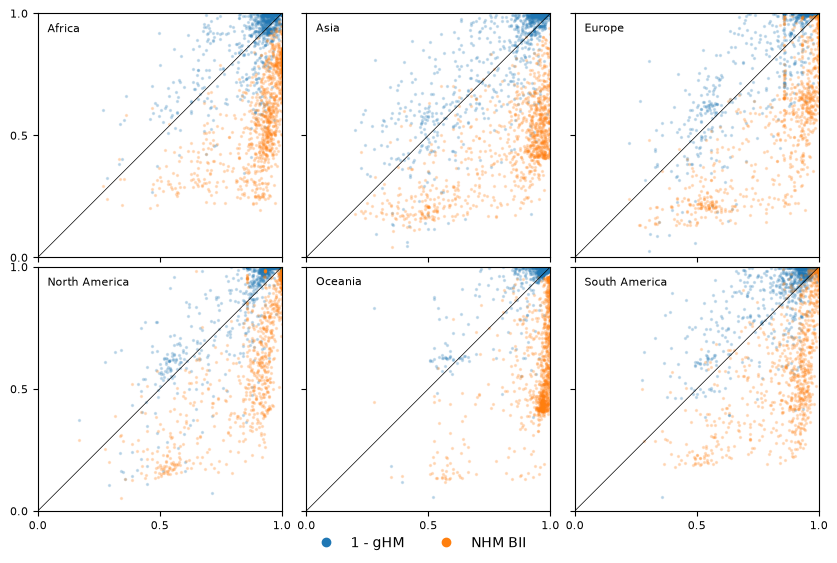

In [2]:
facet_compare(continent, "continent");

## BII vs NHM BII and gHM, by biome

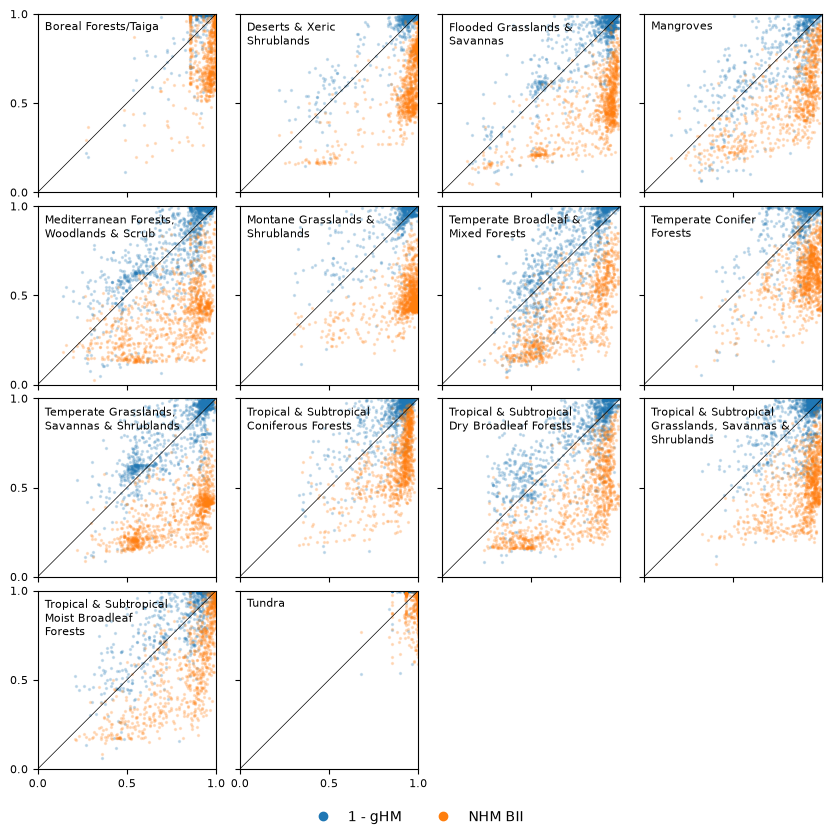

In [3]:
facet_compare(biome, "biome");

## BII4Africa comparison

BII4Africa only covers Africa, so points are taken from the continent sample.

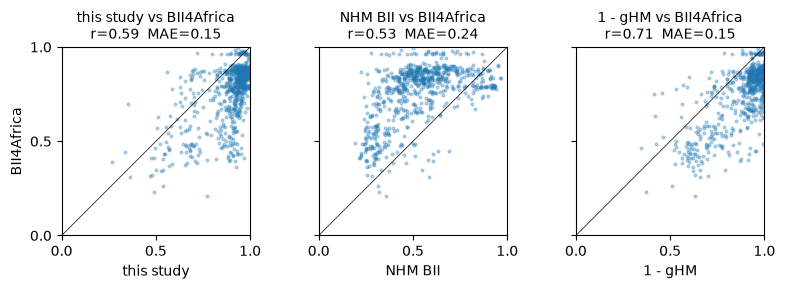

In [4]:
sources = [("bii", "this study"), ("nhm_bii", "NHM BII"), ("ghm", "1 - gHM")]
fig, axes = plt.subplots(1, len(sources), figsize=(A4[0], A4[0] / len(sources)), sharey=True)
for ax, (x, xl) in zip(axes, sources):
    d = continent[[x, "bii_africa"]].dropna()
    r = np.corrcoef(d[x], d["bii_africa"])[0, 1]
    mae = (d[x] - d["bii_africa"]).abs().mean()
    ax.scatter(d[x], d["bii_africa"], s=4, alpha=0.3)
    ax.plot([0, 1], [0, 1], lw=0.5, color="k")
    ax.set(xlim=(0, 1), ylim=(0, 1), aspect="equal", xticks=[0, 0.5, 1], yticks=[0, 0.5, 1])
    ax.set_title(f"{xl} vs BII4Africa\nr={r:.2f}  MAE={mae:.2f}", fontsize=10)
    ax.set_xlabel(xl, fontsize=10)
axes[0].set_ylabel("BII4Africa", fontsize=10)
fig.tight_layout();

## Planetary Computer io-biodiversity comparison

BII 2020 vs. Microsoft Planetary Computer's `io-biodiversity` product, sampled by biome.

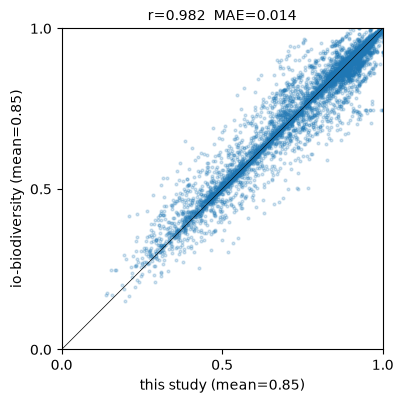

In [5]:
d = biome[["bii", "pc"]].dropna()
r = np.corrcoef(d["bii"], d["pc"])[0, 1]
mae = (d["bii"] - d["pc"]).abs().mean()

fig, ax = plt.subplots(figsize=(A4[0] / 2, A4[0] / 2))
ax.scatter(d["bii"], d["pc"], s=4, alpha=0.2)
ax.plot([0, 1], [0, 1], lw=0.5, color="k")
ax.set(xlim=(0, 1), ylim=(0, 1), aspect="equal", xticks=[0, 0.5, 1], yticks=[0, 0.5, 1])
ax.set_xlabel(f"this study (mean={d['bii'].mean():.2f})", fontsize=10)
ax.set_ylabel(f"io-biodiversity (mean={d['pc'].mean():.2f})", fontsize=10)
ax.set_title(f"r={r:.3f}  MAE={mae:.3f}", fontsize=10)
fig.tight_layout();

## Rate of change, 2017-2025

Per-point linear trend in BII over the 2017-2025 timeseries, by biome, with a 95% confidence interval on the mean trend (normal approximation, `mean ± 1.96·SE`).

In [6]:
YEARS = np.arange(2017, 2026)
YEAR_COLS = [f"bii_{y}" for y in YEARS]
x = YEARS - YEARS.mean()

d = biome.dropna(subset=YEAR_COLS)
d = d.assign(slope=d[YEAR_COLS].to_numpy() @ x / (x ** 2).sum())  # per-point linear trend, Δ BII / yr


def mean_ci(v, z=1.96):
    mean, se = v.mean(), v.std(ddof=1) / np.sqrt(len(v))
    return mean, z * se


groups = sorted(d["biome"].unique()) + ["Overall"]
stats = [mean_ci(d.loc[d["biome"] == g, "slope"].to_numpy() if g != "Overall" else d["slope"].to_numpy())
         for g in groups]
pd.DataFrame({"BII trend, 2017-2025 (loss/yr)": [f"{m:+.4f} ± {ci:.4f}" for m, ci in stats]}, index=groups)

,"BII trend, 2017-2025 (loss/yr)"
Boreal Forests/Taiga,-0.0011 ± 0.0003
Deserts & Xeric Shrublands,-0.0005 ± 0.0003
Flooded Grasslands & Savannas,-0.0008 ± 0.0003
Mangroves,-0.0010 ± 0.0004
"Mediterranean Forests, Woodlands & Scrub",-0.0007 ± 0.0004
Montane Grasslands & Shrublands,-0.0001 ± 0.0002
Temperate Broadleaf & Mixed Forests,-0.0006 ± 0.0003
Temperate Conifer Forests,-0.0005 ± 0.0002
"Temperate Grasslands, Savannas & Shrublands",-0.0016 ± 0.0004
Tropical & Subtropical Coniferous Forests,-0.0007 ± 0.0002


## Correlation and error tables

Pearson `r` and MAE of each comparison dataset against this study, per group and overall.

In [7]:
from IPython.display import display, Markdown

for name, df, col in [("CONTINENT", continent, "continent"), ("BIOME", biome, "biome")]:
    display(Markdown(f"**{name}**"))
    display(stat_table(df, col))

**CONTINENT**

/Users/fgassert/Documents/git/update_bii/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:576: RuntimeWarning: Mean of empty slice
  avg = a.mean(axis, **keepdims_kw)
/Users/fgassert/Documents/git/update_bii/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/Users/fgassert/Documents/git/update_bii/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3015: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/Users/fgassert/Documents/git/update_bii/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/Users/fgassert/Documents/git/update_bii/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/Users/fgassert/Documents/git/up

this study 1 - gHM             NHM BII             BII4Africa  \
                    mean    mean     r   MAE    mean     r   MAE       mean   
Africa              0.91    0.92  0.72  0.06    0.59  0.59  0.32       0.76   
Asia                0.83    0.85  0.82  0.08    0.47  0.65  0.36        NaN   
Europe              0.86    0.88  0.87  0.06    0.64  0.79  0.22        NaN   
North America       0.88    0.89  0.86  0.06    0.68  0.77  0.21        NaN   
Oceania             0.94    0.96  0.80  0.03    0.62  0.47  0.33        NaN   
South America       0.88    0.91  0.77  0.06    0.66  0.65  0.23        NaN   
Overall             0.88    0.90  0.83  0.06    0.61  0.64  0.28       0.76   

                           
                  r   MAE  
Africa         0.59  0.15  
Asia            NaN   NaN  
Europe          NaN   NaN  
North America   NaN   NaN  
Oceania         NaN   NaN  
South America   NaN   NaN  
Overall        0.59  0.15

**BIOME**

/Users/fgassert/Documents/git/update_bii/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:576: RuntimeWarning: Mean of empty slice
  avg = a.mean(axis, **keepdims_kw)
/Users/fgassert/Documents/git/update_bii/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/Users/fgassert/Documents/git/update_bii/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3015: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/Users/fgassert/Documents/git/update_bii/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/Users/fgassert/Documents/git/update_bii/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/Users/fgassert/Documents/git/up

this study 1 - gHM        \
                                                         mean    mean     r   
Boreal Forests/Taiga                                     0.96    0.98  0.70   
Deserts & Xeric Shrublands                               0.93    0.94  0.88   
Flooded Grasslands & Savannas                            0.84    0.86  0.85   
Mangroves                                                0.81    0.82  0.82   
Mediterranean Forests, Woodlands & Scrub                 0.75    0.77  0.77   
Montane Grasslands & Shrublands                          0.92    0.95  0.77   
Temperate Broadleaf & Mixed Forests                      0.72    0.74  0.80   
Temperate Conifer Forests                                0.89    0.93  0.71   
Temperate Grasslands, Savannas & Shrublands              0.78    0.80  0.80   
Tropical & Subtropical Coniferous Forests                0.87    0.91  0.75   
Tropical & Subtropical Dry Broadleaf Forests             0.74    0.77  0.80   
Tropical & Subtropical Grasslands, Savannas & S...       0.88    0.89  0.65   
Tropical & Subtropical Moist Broadleaf Forests           0.85    0.88  0.84   
Tundra                                                   0.99    1.00  0.36   
Overall                                                  0.85    0.87  0.83   

                                                         NHM BII              \
                                                     MAE    mean     r   MAE   
Boreal Forests/Taiga                                0.04    0.81  0.49  0.16   
Deserts & Xeric Shrublands                          0.04    0.62  0.65  0.30   
Flooded Grasslands & Savannas                       0.07    0.48  0.65  0.36   
Mangroves                                           0.09    0.54  0.70  0.27   
Mediterranean Forests, Woodlands & Scrub            0.10    0.40  0.53  0.36   
Montane Grasslands & Shrublands                     0.05    0.49  0.42  0.43   
Temperate Broadleaf & Mixed Forests                 0.11    0.41  0.72  0.31   
Temperate Conifer Forests                           0.07    0.62  0.47  0.28   
Temperate Grasslands, Savannas & Shrublands         0.08    0.36  0.64  0.42   
Tropical & Subtropical Coniferous Forests           0.07    0.65  0.60  0.23   
Tropical & Subtropical Dry Broadleaf Forests        0.10    0.44  0.68  0.30   
Tropical & Subtropical Grasslands, Savannas & S...  0.07    0.51  0.50  0.37   
Tropical & Subtropical Moist Broadleaf Forests      0.07    0.66  0.78  0.19   
Tundra                                              0.01    0.95  0.32  0.05   
Overall                                             0.07    0.57  0.66  0.29   

                                                   BII4Africa              
                                                         mean     r   MAE  
Boreal Forests/Taiga                                      NaN   NaN   NaN  
Deserts & Xeric Shrublands                               0.84  0.83  0.10  
Flooded Grasslands & Savannas                            0.82  0.44  0.12  
Mangroves                                                0.68  0.38  0.20  
Mediterranean Forests, Woodlands & Scrub                 0.58  0.64  0.27  
Montane Grasslands & Shrublands                          0.57  0.55  0.18  
Temperate Broadleaf & Mixed Forests                       NaN   NaN   NaN  
Temperate Conifer Forests                                 NaN   NaN   NaN  
Temperate Grasslands, Savannas & Shrublands               NaN   NaN   NaN  
Tropical & Subtropical Coniferous Forests                 NaN   NaN   NaN  
Tropical & Subtropical Dry Broadleaf Forests             0.78 -0.72  0.19  
Tropical & Subtropical Grasslands, Savannas & S...       0.75  0.53  0.16  
Tropical & Subtropical Moist Broadleaf Forests           0.76  0.47  0.16  
Tundra                                                    NaN   NaN   NaN  
Overall                                                  0.75  0.59  0.15